# TP - Régularisation des réseaux de neurones

Comparaison des effets de la régularisation L1, L2 et ElasticNet sur un modèle sur-paramétré.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

# Création de données (2 classes)
X, y = make_moons(n_samples=300, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Modèle très complexe (trop de neurones)
overfit_model = Sequential([
    Dense(500, activation='relu', input_shape=(2,)),
    Dense(500, activation='relu'),
    Dense(500, activation='relu'),
    Dense(1, activation='sigmoid')
])

overfit_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = overfit_model.fit(X_train, y_train,
                           epochs=200,
                           validation_data=(X_test, y_test),
                           verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


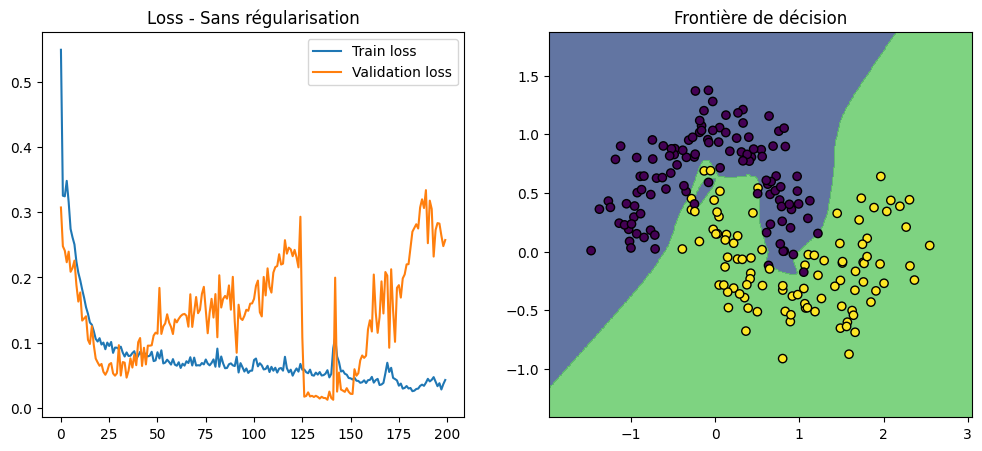

In [2]:
# Courbes d'apprentissage
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title('Loss - Sans régularisation')
plt.legend()

# Frontière de décision
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    h = 0.01
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()], verbose=0) > 0.5
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
    plt.title("Frontière de décision")

plt.subplot(1, 2, 2)
plot_decision_boundary(overfit_model, X_train, y_train)
plt.show()

In [3]:
from tensorflow.keras.regularizers import l2

# Même architecture mais avec régularisation L2
regularized_model = Sequential([
    Dense(500, activation='relu', input_shape=(2,), kernel_regularizer=l2(0.01)),
    Dense(500, activation='relu', kernel_regularizer=l2(0.01)),
    Dense(500, activation='relu', kernel_regularizer=l2(0.01)),
    Dense(1, activation='sigmoid')
])

regularized_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

reg_history = regularized_model.fit(X_train, y_train,
                                   epochs=200,
                                   validation_data=(X_test, y_test),
                                   verbose=0)

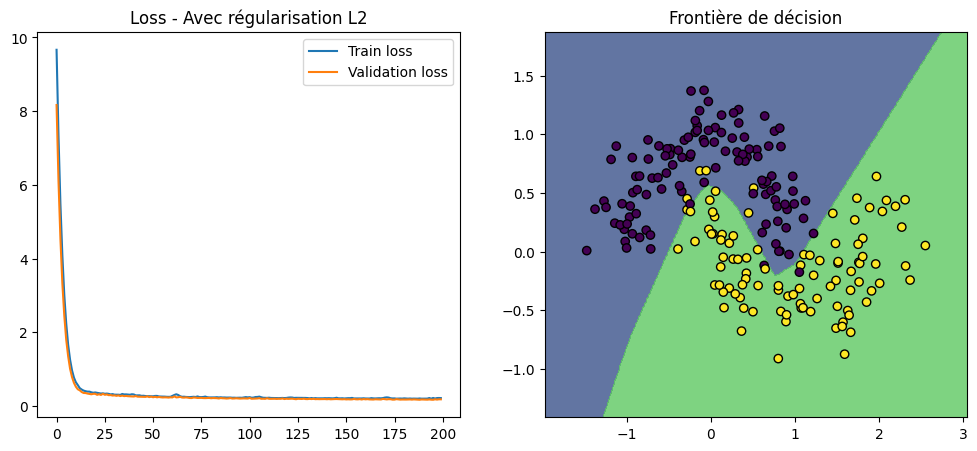

In [4]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(reg_history.history['loss'], label='Train loss')
plt.plot(reg_history.history['val_loss'], label='Validation loss')
plt.title('Loss - Avec régularisation L2')
plt.legend()

plt.subplot(1, 2, 2)
plot_decision_boundary(regularized_model, X_train, y_train)
plt.show()

## Exercice : Régularisation L1 et ElasticNet

### 1. Création des modèles L1 et ElasticNet

In [5]:
from tensorflow.keras.regularizers import l1, l1_l2

wl1_model = Sequential([
    Dense(500, activation='relu', input_shape=(2,), kernel_regularizer=l1(0.01)),
    Dense(500, activation='relu', kernel_regularizer=l1(0.01)),
    Dense(500, activation='relu', kernel_regularizer=l1(0.01)),
    Dense(1, activation='sigmoid')
])

l1_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_l1 = l1_model.fit(X_train, y_train,
                          epochs=200,
                          validation_data=(X_test, y_test),
                          verbose=0)

elastic_model = Sequential([
    Dense(500, activation='relu', input_shape=(2,), kernel_regularizer=l1_l2(l1=0.01, l2=0.01)),
    Dense(500, activation='relu', kernel_regularizer=l1_l2(l1=0.01, l2=0.01)),
    Dense(500, activation='relu', kernel_regularizer=l1_l2(l1=0.01, l2=0.01)),
    Dense(1, activation='sigmoid')
])

elastic_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_elastic = elastic_model.fit(X_train, y_train,
                                    epochs=200,
                                    validation_data=(X_test, y_test),
                                    verbose=0)

print("Entraînement terminé pour L1 et ElasticNet.")

Entraînement terminé pour L1 et ElasticNet.


### 2. Courbes d'apprentissage et frontière de décision - L1

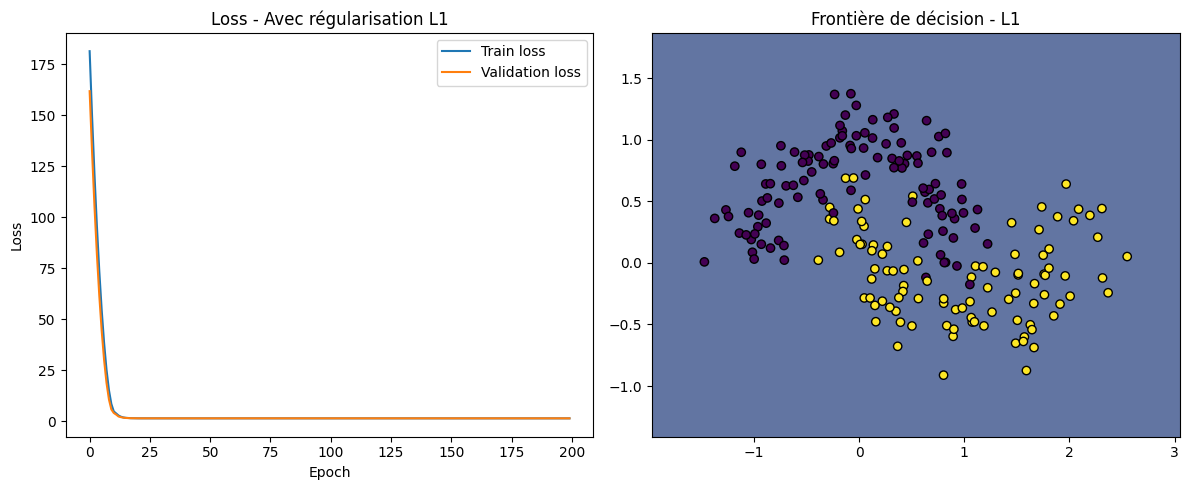

In [6]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_l1.history['loss'], label='Train loss')
plt.plot(history_l1.history['val_loss'], label='Validation loss')
plt.title('Loss - Avec régularisation L1')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plot_decision_boundary(l1_model, X_train, y_train)
plt.title('Frontière de décision - L1')
plt.tight_layout()
plt.show()

### 3. Courbes d'apprentissage et frontière de décision - ElasticNet

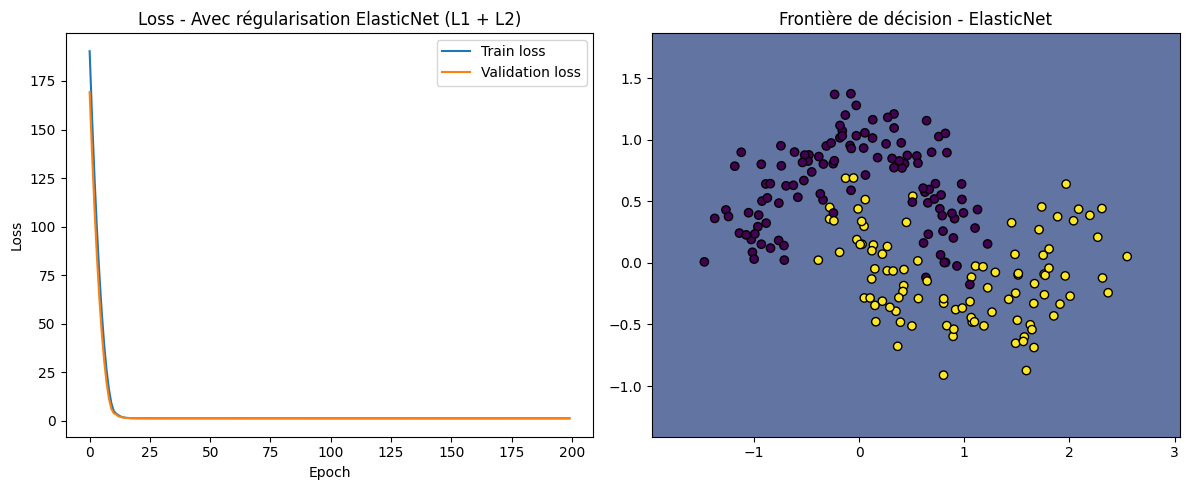

In [7]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_elastic.history['loss'], label='Train loss')
plt.plot(history_elastic.history['val_loss'], label='Validation loss')
plt.title('Loss - Avec régularisation ElasticNet (L1 + L2)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plot_decision_boundary(elastic_model, X_train, y_train)
plt.title('Frontière de décision - ElasticNet')
plt.tight_layout()
plt.show()

### 4. Comparaison finale des 4 modèles

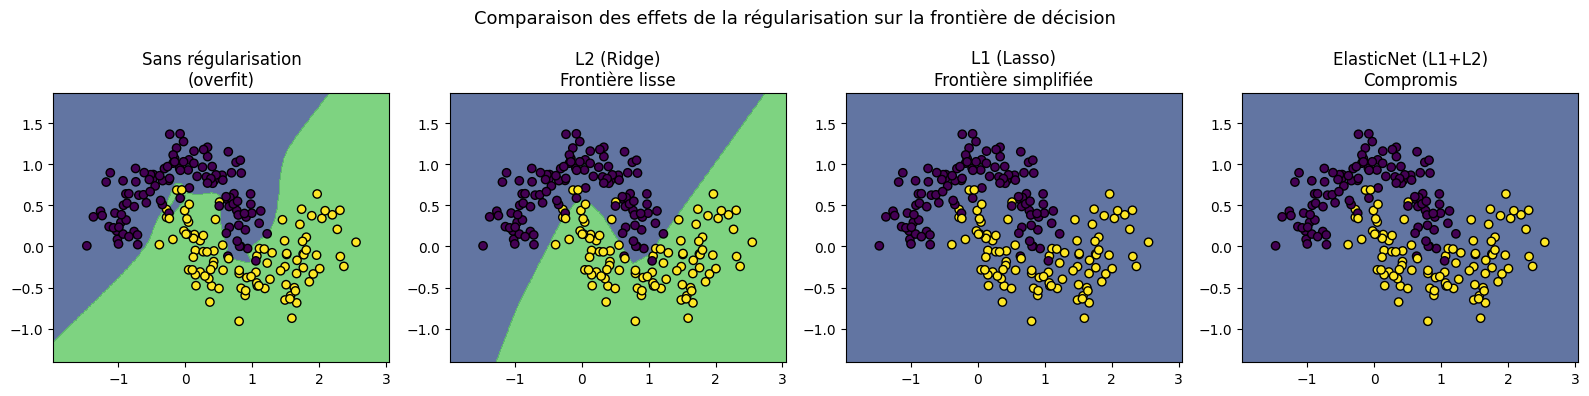

In [8]:
plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plot_decision_boundary(overfit_model, X_train, y_train)
plt.title('Sans régularisation\n(overfit)')

plt.subplot(1, 4, 2)
plot_decision_boundary(regularized_model, X_train, y_train)
plt.title('L2 (Ridge)\nFrontière lisse')

plt.subplot(1, 4, 3)
plot_decision_boundary(l1_model, X_train, y_train)
plt.title('L1 (Lasso)\nFrontière simplifiée')

plt.subplot(1, 4, 4)
plot_decision_boundary(elastic_model, X_train, y_train)
plt.title('ElasticNet (L1+L2)\nCompromis')

plt.suptitle('Comparaison des effets de la régularisation sur la frontière de décision', fontsize=13)
plt.tight_layout()
plt.show()

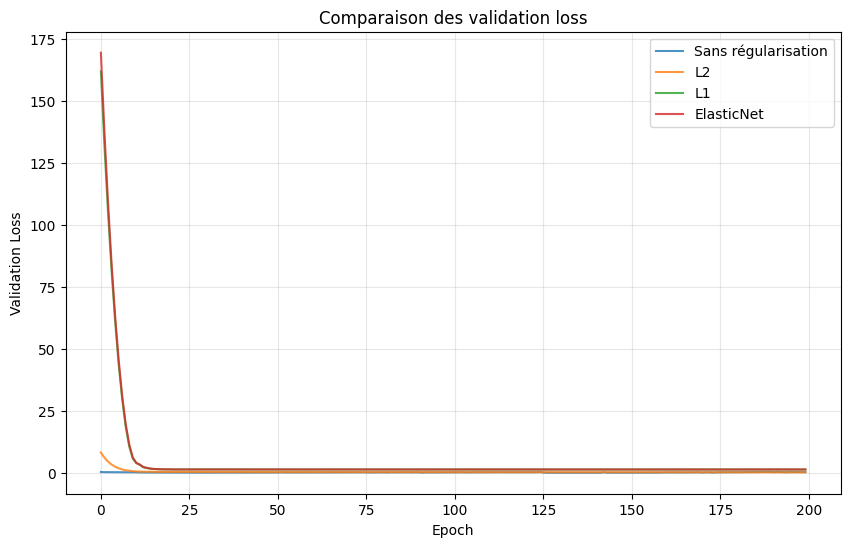

=== Performances finales (validation) ===
Sans régularisation : val_loss = 0.2574 | val_acc = 0.9778
L2                  : val_loss = 0.1819 | val_acc = 0.9667
L1                  : val_loss = 1.3174 | val_acc = 0.4222
ElasticNet          : val_loss = 1.3150 | val_acc = 0.4222


In [9]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['val_loss'], label='Sans régularisation', alpha=0.8)
plt.plot(reg_history.history['val_loss'], label='L2', alpha=0.8)
plt.plot(history_l1.history['val_loss'], label='L1', alpha=0.8)
plt.plot(history_elastic.history['val_loss'], label='ElasticNet', alpha=0.8)
plt.title('Comparaison des validation loss')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("=== Performances finales (validation) ===")
print(f"Sans régularisation : val_loss = {history.history['val_loss'][-1]:.4f} | val_acc = {history.history['val_accuracy'][-1]:.4f}")
print(f"L2                  : val_loss = {reg_history.history['val_loss'][-1]:.4f} | val_acc = {reg_history.history['val_accuracy'][-1]:.4f}")
print(f"L1                  : val_loss = {history_l1.history['val_loss'][-1]:.4f} | val_acc = {history_l1.history['val_accuracy'][-1]:.4f}")
print(f"ElasticNet          : val_loss = {history_elastic.history['val_loss'][-1]:.4f} | val_acc = {history_elastic.history['val_accuracy'][-1]:.4f}")